# Imports

In [1]:
import batchalign as ba
from tqdm import tqdm
import argparse
import requests
from bs4 import BeautifulSoup
import re
from tqdm import tqdm
import os
import pandas as pd
import stanza
from pprint import pprint
import math
from dataclasses import dataclass
from typing import List, Dict, Any, Optional, Tuple
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor
import numpy as np
import json

# Data Importing

In [2]:
raw_train_news_df = pd.read_csv("F:/NT@B/Microsoft-sp26/MINDlarge_train/news.tsv", sep="\t")
raw_test_news_df = pd.read_csv("F:/NT@B/Microsoft-sp26/MINDlarge_test/news.tsv", sep="\t")

header_data = ["id", "category", "subcategory", "title", "abstract", "url", "title_entities", "abstract_entities"]
raw_train_news_df.columns = header_data
raw_test_news_df.columns = header_data

train_df, test_df = raw_train_news_df, raw_test_news_df

len(set(raw_train_news_df["category"])), len(set(raw_train_news_df["subcategory"]))

(18, 285)

In [3]:
def load_glove_embeddings(file_path):
    """
    Loads GloVe embeddings from a file into a dictionary.
    """
    embeddings_dict = {}
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.asarray(values[1:], dtype='float32')
            embeddings_dict[word] = vector
    return embeddings_dict

# Specify the path to your downloaded GloVe file (e.g., 'glove.6B.100d.txt')
glove_file_path = r"F:\NT@B\Microsoft-sp26\wiki_giga_2024_50_MFT20_vectors_seed_123_alpha_0.75_eta_0.075_combined.txt"
def load_glove_embeddings_safe(file_path, embedding_dim=50):
    embeddings_dict = {}
    skipped = 0
    cache_path = "embeddings_dict.json"
    if os.path.exists(cache_path):
        with open(cache_path, 'r', encoding='utf-8') as file:
            raw = json.load(file)
            embeddings_dict = {k: np.asarray(v, dtype="float32") for k, v in tqdm(raw.items())}
    else:
        with open(file_path, "r", encoding="utf-8") as f:
            for line in tqdm(f):
                values = line.strip().split()
                if not values:
                    continue

                # Skip optional header line like: "400000 50"
                if len(values) == 2 and values[0].isdigit() and values[1].isdigit():
                    continue

                # Need at least: token + embedding_dim floats
                if len(values) < embedding_dim + 1:
                    skipped += 1
                    continue

                # Support tokens that may contain spaces by taking last embedding_dim values as vector
                word = " ".join(values[:-embedding_dim])
                vec_tokens = values[-embedding_dim:]

                try:
                    embeddings_dict[word] = np.asarray(vec_tokens, dtype="float32")
                except ValueError:
                    skipped += 1
                    continue
        with open(cache_path, 'w', encoding='utf-8') as f:
            json.dump({k: v.tolist() for k, v in tqdm(embeddings_dict.items())}, f)

    print(f"Loaded {len(embeddings_dict)} embeddings. Skipped {skipped} malformed lines.")
    return embeddings_dict

embeddings_dict = load_glove_embeddings_safe(glove_file_path, embedding_dim=50)

100%|██████████| 1291147/1291147 [00:04<00:00, 293072.86it/s]


Loaded 1291147 embeddings. Skipped 0 malformed lines.


In [4]:
# for category in tqdm(set(raw_train_news_df["category"])):
#     print(category, len(set(raw_train_news_df[raw_train_news_df["category"] == category]["subcategory"])))

# Dataframe Creation

In [5]:
train_news_df = raw_train_news_df[raw_train_news_df["category"] == "news"]
test_news_df = raw_test_news_df[raw_test_news_df["category"] == "news"]

train_news_df = train_news_df.reset_index(drop=True)
test_news_df = test_news_df.reset_index(drop=True)

train_news_df = train_news_df[~train_news_df["abstract"].isna()]
test_news_df = test_news_df[~test_news_df["abstract"].isna()]

test_news_df = test_news_df[~test_news_df["id"].isin(train_news_df["id"])]
test_news_df = test_news_df.reset_index(drop=True)

test_news_df.loc[1, "abstract"], test_news_df.loc[1, "abstract_entities"]

('Apple rules the tablet roost, but is its newest iPad Pro a worthy addition to the iPad line?',
 '[{"Label": "IPad Pro", "Type": "U", "WikidataId": "Q20962060", "Confidence": 1.0, "OccurrenceOffsets": [48], "SurfaceForms": ["iPad Pro"]}, {"Label": "Apple Inc.", "Type": "O", "WikidataId": "Q312", "Confidence": 0.999, "OccurrenceOffsets": [0], "SurfaceForms": ["Apple"]}]')

# Category Classifier

## Tokenization Process

In [6]:
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, GaussianNB, ComplementNB
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC

# test_wo_train_df = raw_test_news_df[~raw_test_news_df["id"].isin(raw_train_news_df["id"])]
# test_wo_train_df = test_wo_train_df[test_wo_train_df['abstract'].notna()]

train_df = train_df[train_df['abstract'].notna()]

cat_to_num = {}
for i, cat in enumerate(set(train_df['category'])):
    cat_to_num[cat] = i
train_df.loc[:, 'category_encoded'] = train_df['category'].map(cat_to_num)

train_df_reasonable = train_df[~train_df['category'].isin(["northamerica", "movies", "games", "entertainment", "middleeast", "kids"])]

tfidf = TfidfVectorizer(sublinear_tf=True, min_df=1, ngram_range=(1, 2), stop_words='english')
feature = tfidf.fit_transform(train_df['title'])
#feature.shape

C:\Users\great\AppData\Local\Temp\ipykernel_31704\1264273971.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df.loc[:, 'category_encoded'] = train_df['category'].map(cat_to_num)


In [7]:
import nltk
from nltk.corpus import stopwords

def preprocess_text(text: str):
    stop_words = set(stopwords.words('english'))
    words = nltk.word_tokenize(text)
    filtered_words = [word for word in words if word.lower() not in stop_words]
    return filtered_words

preprocessed_title = [preprocess_text(title) for title in tqdm(train_df_reasonable['title'])]
preprocessed_abstract = [preprocess_text(abstract) for abstract in tqdm(train_df_reasonable['abstract'])]
train_df_reasonable['abstract_tokenized'] = preprocessed_abstract
train_df_reasonable['title_tokenized'] = preprocessed_title
# maxima = max(len(title) for title in preprocessed_title)

# vector_preproc = [[embeddings_dict.get(word.lower(), np.zeros(50)) for word in title] for title in tqdm(preprocessed_title)]
# for vector in vector_preproc:
#     while len(vector) < maxima:
#         vector.append(np.zeros(50))
# vector_preproc = np.array(vector_preproc)
# vector_preproc.shape

100%|██████████| 94413/94413 [00:33<00:00, 2816.90it/s]
C:\Users\great\AppData\Local\Temp\ipykernel_31704\2412040070.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df_reasonable['abstract_tokenized'] = preprocessed_abstract
C:\Users\great\AppData\Local\Temp\ipykernel_31704\2412040070.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df_reasonable['title_tokenized'] = preprocessed_title


In [9]:
proxy_vector = vector_preproc.reshape(vector_preproc.shape[0], -1)
len(list(proxy_vector))

28281

In [10]:
from sklearn.decomposition import PCA
pca = PCA(n_components=100)
test_wo_train_df['title_vector'] = list(proxy_vector)
test_wo_train_df['title_vector_condensed'] = list(pca.fit_transform(list(proxy_vector))) 

C:\Users\great\AppData\Local\Temp\ipykernel_3664\538985390.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_wo_train_df['title_vector'] = list(proxy_vector)
C:\Users\great\AppData\Local\Temp\ipykernel_3664\538985390.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_wo_train_df['title_vector_condensed'] = list(pca.fit_transform(list(proxy_vector)))


## ONEvREST(SVC) Classifier

In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(test_wo_train_df['title_vector_condensed'], test_wo_train_df['category_encoded'].astype(int), test_size=0.3, random_state=42)

clf = LogisticRegression(multi_class='multinomial', solver='saga', max_iter=100).fit(list(X_train), Y_train)

predictions_ovr = clf.predict(list(X_test))

from sklearn.metrics import classification_report
print(classification_report(Y_test, predictions_ovr))


C:\Users\great\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


              precision    recall  f1-score   support

           0       0.55      0.77      0.64      2699
           1       0.44      0.24      0.31       496
           2       0.51      0.29      0.37       196
           3       0.38      0.13      0.20       462
           4       0.39      0.22      0.28       441
           5       0.00      0.00      0.00        11
           6       0.17      0.02      0.04        51
           7       0.22      0.07      0.11        54
           8       0.36      0.17      0.23       310
           9       0.26      0.05      0.08        99
          10       0.82      0.89      0.86      2722
          11       0.62      0.53      0.57       348
          12       0.38      0.34      0.36       124
          13       0.52      0.43      0.47       179
          14       0.60      0.52      0.55       293

    accuracy                           0.63      8485
   macro avg       0.41      0.31      0.34      8485
weighted avg       0.60   

C:\Users\great\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
models = [
    RandomForestClassifier(n_estimators=200, max_depth=3, random_state=0),
    SVC(random_state=0),
    LinearSVC(C=1.0),
    # MultinomialNB(), Only positive values allowed
    GaussianNB(),
    # ComplementNB(), Only positive values allowed
    OneVsRestClassifier(SVC(random_state=0)),
    LogisticRegression(multi_class='multinomial', solver='saga', random_state=0, max_iter=100),
]
CV = 2
cv_df = pd.DataFrame(index=range(CV * len(models)))
entries = []
for model in tqdm(models):
  model_name = model.__class__.__name__
  accuracies = cross_val_score(model, list(test_wo_train_df['title_vector_condensed']), test_wo_train_df['category_encoded'].astype(int), scoring='accuracy', cv=CV)
  for fold_idx, accuracy in enumerate(accuracies):
    entries.append((model_name, fold_idx, accuracy))
cv_df = pd.DataFrame(entries, columns=['model_name', 'fold_idx', 'accuracy'])

 83%|████████▎ | 5/6 [08:29<02:40, 160.84s/it]C:\Users\great\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\great\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
C:\Users\great\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
C:\Users\great\AppData\Roaming\Python\Python312\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached wh

In [29]:
cv_df.groupby('model_name').accuracy.mean()

model_name
GaussianNB                0.556027
LinearSVC                 0.540151
LogisticRegression        0.622114
OneVsRestClassifier       0.638945
RandomForestClassifier    0.527103
SVC                       0.564761
Name: accuracy, dtype: float64

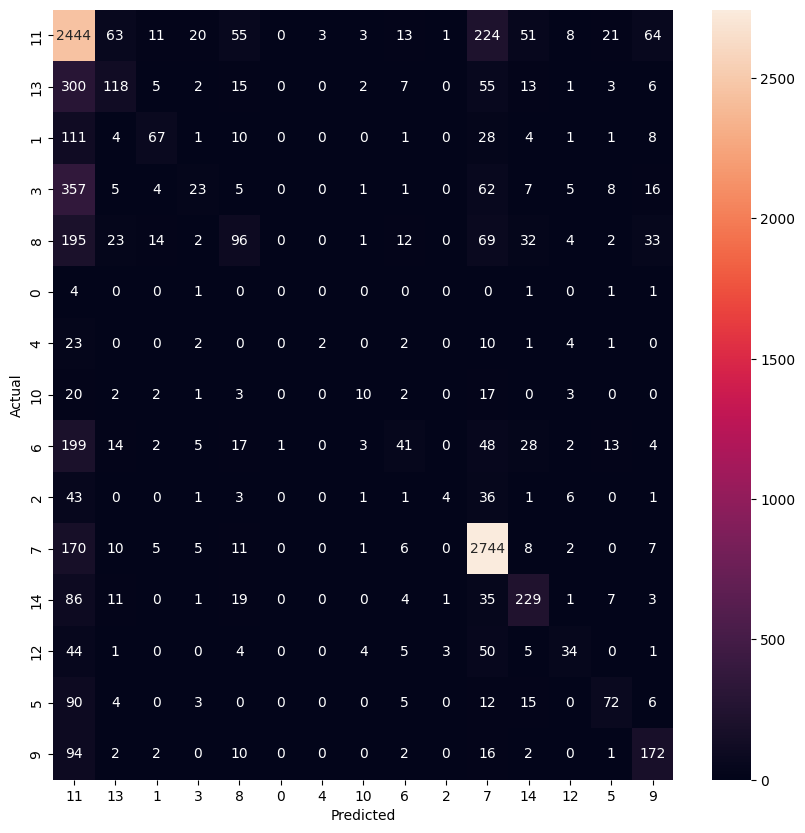

              precision    recall  f1-score   support

          11       0.58      0.82      0.68      2981
          13       0.46      0.22      0.30       527
           1       0.60      0.28      0.39       236
           3       0.34      0.05      0.08       494
           8       0.39      0.20      0.26       483
           0       0.00      0.00      0.00         8
           4       0.40      0.04      0.08        45
          10       0.38      0.17      0.23        60
           6       0.40      0.11      0.17       377
           2       0.44      0.04      0.08        97
           7       0.81      0.92      0.86      2969
          14       0.58      0.58      0.58       397
          12       0.48      0.23      0.31       151
           5       0.55      0.35      0.43       207
           9       0.53      0.57      0.55       301

    accuracy                           0.65      9333
   macro avg       0.46      0.31      0.33      9333
weighted avg       0.61   

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
model = OneVsRestClassifier(SVC(random_state=0))
X_train, X_test, y_train, y_test, indices_train, indices_test = train_test_split(list(test_wo_train_df['title_vector_condensed']), test_wo_train_df['category_encoded'].astype(int), test_wo_train_df.index, test_size=0.33, random_state=0)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
from sklearn.metrics import confusion_matrix
conf_mat = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10,10))
sns.heatmap(conf_mat, annot=True, fmt='d',
            xticklabels=test_wo_train_df['category_encoded'].astype(int).unique(), yticklabels=test_wo_train_df['category_encoded'].astype(int).unique())
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()
print(sklearn.metrics.classification_report(y_test, y_pred, target_names=test_wo_train_df['category_encoded'].astype(int).unique().astype(str)))

## Trying to improve accuracy

In [13]:
x_train, x_test, y_train, y_test = train_test_split(train_df_reasonable['title_tokenized'], 
                                                    train_df_reasonable['category_encoded'].astype(int), 
                                                    test_size=0.3, 
                                                    random_state=0, 
                                                    #stratify=train_df_reasonable['category_encoded'].astype(int)
                                                    )
x_train = [" ".join(doc) for doc in x_train]
x_test = [" ".join(doc) for doc in x_test]

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

models = [
    # RandomForestClassifier(random_state=0),
    # SVC(),
    #LinearSVC(),
    # MultinomialNB(), # Only positive values allowed
    # GaussianNB(),
    # ComplementNB(), # Only positive values allowed
    # OneVsRestClassifier(ComplementNB()),
    # OneVsRestClassifier(LinearSVC()),
    #LogisticRegression(multi_class='multinomial', solver='saga', max_iter=100),
]

for model in tqdm(models):
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf", model)
    ])

    param_grid = {
        "tfidf__ngram_range": [(1,1), (1,2), (1,3)],
        "tfidf__min_df": [1, 2, 5],
        "tfidf__max_df": [0.9, 1.0],
        "tfidf__sublinear_tf": [True, False]
    }

    if (isinstance(model, OneVsRestClassifier) and isinstance(model.estimator, LinearSVC)):
        param_grid["clf__estimator__C"] = [0.8, 0.9, 1, 1.1, 1.2]
    # elif isinstance(model, LinearSVC) or isinstance(model, SVC):
    #     param_grid["clf__C"] = [0.8, 0.9, 1, 1.1, 1.2]
    elif isinstance(model, ComplementNB) or isinstance(model, MultinomialNB) or isinstance(model, GaussianNB):
        param_grid["clf__alpha"] = [0.8, 0.9, 1, 1.1, 1.2]
    # elif isinstance(model, RandomForestClassifier):
    #     param_grid["clf__n_estimators"] = [100, 200]
    #     param_grid["clf__max_depth"] = [3, 5, None]

    grid = GridSearchCV(
        pipeline,
        param_grid,
        cv=2,
        scoring="f1_macro",
        n_jobs=-1
    )

    grid.fit(x_train, y_train)
    #y_pred = grid.predict(x_test)


    print(f"---------------- Results for model: {model.__class__.__name__} -----------------------")
    print("Best params:", grid.best_params_)
    print("Best CV Accuracy:", grid.best_score_)
    print("Test accuracy:", grid.score(x_test, y_test))
    #print("Accuracy:", accuracy_score(y_test, y_pred))
    #print("Macro F1:", f1_score(y_test, y_pred, average="macro"))
    #print("Weighted F1:", f1_score(y_test, y_pred, average="weighted"))
    #print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

  0%|          | 0/2 [00:00<?, ?it/s]

---------------- Results for model: OneVsRestClassifier -----------------------
Best params: {'clf__estimator__alpha': 0.8, 'tfidf__max_df': 0.9, 'tfidf__min_df': 2, 'tfidf__ngram_range': (1, 1), 'tfidf__sublinear_tf': True}
Best CV Accuracy: 0.5615839339040489


 50%|█████     | 1/2 [03:18<03:18, 198.63s/it]

Test accuracy: 0.6036004263539585
---------------- Results for model: OneVsRestClassifier -----------------------
Best params: {'clf__estimator__C': 1.2, 'tfidf__max_df': 0.9, 'tfidf__min_df': 1, 'tfidf__ngram_range': (1, 2), 'tfidf__sublinear_tf': True}
Best CV Accuracy: 0.5819318702591568


100%|██████████| 2/2 [10:59<00:00, 329.66s/it]

Test accuracy: 0.6238547340946196


## OneVsRest Classifier with Estimator LinearSVC() seems to have best performance

In [87]:
x_train, x_test, y_train, y_test = train_test_split(train_df_reasonable['title_tokenized'], train_df_reasonable['category_encoded'].astype(int), test_size=0.3, random_state=0)
x_train = [" ".join(doc) for doc in x_train]
x_test = [" ".join(doc) for doc in x_test]

tfidf = TfidfVectorizer(sublinear_tf=True, min_df=1, ngram_range=(1, 2), stop_words='english', max_df=0.9)
X_train_tfidf = tfidf.fit_transform(x_train)
X_test_tfidf = tfidf.transform(x_test)
model = OneVsRestClassifier(LinearSVC(C=1.2))
model.fit(X_train_tfidf, y_train)

predictions_onevrest = model.predict(X_test_tfidf)

from sklearn.metrics import classification_report
print(classification_report(y_test, predictions_onevrest, target_names=[str(i) for i in set(train_df_reasonable['category_encoded'].astype(int))]))

              precision    recall  f1-score   support

           0       0.62      0.47      0.53      1293
           4       0.72      0.60      0.65       823
           5       0.81      0.67      0.73       381
           6       0.41      0.16      0.24      1331
           7       0.57      0.43      0.49      1436
           8       0.68      0.62      0.65       844
           9       0.73      0.72      0.73      1295
          10       0.92      0.95      0.94      8705
          11       0.63      0.38      0.48       380
          12       0.70      0.83      0.76      8964
          14       0.67      0.72      0.69      1155
          16       0.64      0.57      0.60      1717

    accuracy                           0.75     28324
   macro avg       0.67      0.59      0.62     28324
weighted avg       0.74      0.75      0.74     28324



In [84]:
for cat in cat_to_num:
    print(f"{cat}: {len(train_df_reasonable[train_df_reasonable['category'] == cat])}")

lifestyle: 4255
northamerica: 0
movies: 0
games: 0
autos: 2756
music: 1220
video: 4563
travel: 4605
health: 2815
foodanddrink: 4319
sports: 29626
tv: 1291
news: 29365
entertainment: 0
weather: 3820
middleeast: 0
finance: 5778
kids: 0


# CLAN Analysis

## Example Execution

In [ ]:
doc = ba.Document.new("Hello, this is a transcript! I have two utterances.", 
                      media_path="audio.mp3", lang="eng")

# navigating the document
first_utterance = doc[0]
first_form = doc[0][0]
the_comma = doc[0][1]

assert the_comma.text == ','
assert the_comma.type == ba.TokenType.PUNCT

# taking a transcript
sentences = doc.transcript(include_tiers=True, strip=True)

In [ ]:
sentences

## Mind Execution

In [ ]:
CLAUSAL_DEPRELS = {"ccomp", "xcomp", "advcl", "acl", "acl:relcl", "parataxis"}
SENT_LABELS = {"S", "SBAR", "SBARQ", "SINV", "SQ"}
PUNCT_TAGS = {".", ",", ":", "``", "''", "-LRB-", "-RRB-", "#", "$"}

def clause_count_from_dependencies(stanza_sentence):
    count = 0

    # main clause: one root predicate
    root_words = [w for w in stanza_sentence.words if w.head == 0]
    if root_words:
        count += 1

    # embedded/subordinate clauses
    for w in stanza_sentence.words:
        if w.deprel in CLAUSAL_DEPRELS:
            count += 1

    return count

def clause_density(stanza_doc):
    densities = []
    for sent in stanza_doc.sentences:
        n_clauses = clause_count_from_dependencies(sent)
        densities.append(n_clauses)  # per sentence
    return densities

def dependency_lengths(stanza_sentence):
    dists = []
    for w in stanza_sentence.words:
        if w.head != 0:  # skip root
            dists.append(abs(w.id - w.head))
    return dists

def mean_dependency_length(stanza_doc):
    dist_per_sentence = []
    for sent in stanza_doc.sentences:
        dists = dependency_lengths(sent)
        dist_per_sentence.append(sum(dists) / len(dists) if dists else 0.0)
    return dist_per_sentence

def is_leaf(node) -> bool:
    return len(node.children) == 0

def is_preterminal(node) -> bool:
    return len(node.children) == 1 and is_leaf(node.children[0])

def is_punct_preterminal(node) -> bool:
    return is_preterminal(node) and node.label in PUNCT_TAGS

def leaf_text(node) -> str:
    return node.label

def iter_leaf_paths(node, path=None):
    """
    Yield tuples: (leaf_node, path)
    where path is a list of (parent_node, child_index) from root down to the leaf.
    """
    if path is None:
        path = []

    if is_leaf(node):
        yield node, path
        return

    for i, child in enumerate(node.children):
        yield from iter_leaf_paths(child, path + [(node, i)])

def iter_nodes(node):
    yield node
    for child in node.children:
        yield from iter_nodes(child)

def count_non_punct_words(tree) -> int:
    count = 0
    for node in iter_nodes(tree):
        if is_preterminal(node) and not is_punct_preterminal(node):
            count += 1
    return count

def left_embedding_depth(tree) -> int:
    """
    Constituency-based operationalization:
    For each leaf path, count how many ancestors keep the leaf on the left edge
    of an unfinished constituent, i.e. the child is the first child and the parent
    has material to the right.

    Sentence score = maximum such depth across leaves.
    """
    max_depth = 0

    for leaf, path in iter_leaf_paths(tree):
        depth = 0
        for parent, child_idx in path:
            if is_preterminal(parent):
                continue
            if child_idx == 0 and len(parent.children) > 1:
                depth += 1
        max_depth = max(max_depth, depth)

    return max_depth

def center_embedding_depth(tree) -> int:
    """
    Constituency-based operationalization:
    Count nested sentential constituents (S, SBAR, SBARQ, SINV, SQ)
    that occur in a non-final position of another sentential constituent.

    This captures center-embedding rather than simple right-branching.
    """
    def helper(node, active_center_depth=0):
        best = active_center_depth

        for i, child in enumerate(node.children):
            child_depth = active_center_depth

            if child.label in SENT_LABELS and not is_preterminal(child):
                # Embedded clause inside a non-final position -> center embedding increment
                if i < len(node.children) - 1:
                    child_depth += 1

            best = max(best, helper(child, child_depth))

        return best

    return helper(tree, 0)

def yngve_scores(tree) -> Dict[str, Any]:
    """
    For each leaf:
      score = sum over ancestors of the number of right siblings.
    Returns per-word scores plus sum/mean/max over words.
    """
    per_word = []

    for leaf, path in iter_leaf_paths(tree):
        # Ignore punctuation leaves by checking their preterminal parent
        if len(path) >= 1:
            parent, _ = path[-1]
            if is_punct_preterminal(parent):
                continue

        score = 0
        for parent, child_idx in path:
            score += (len(parent.children) - child_idx - 1)

        per_word.append({
            "word": leaf_text(leaf),
            "score": score
        })

    values = [x["score"] for x in per_word]
    return {
        "per_word": per_word,
        "sum": sum(values),
        "mean": (sum(values) / len(values)) if values else 0.0,
        "max": max(values) if values else 0
    }

def frazier_scores(tree) -> Dict[str, Any]:
    """
    A compact, reproducible Frazier-style implementation.

    For each leaf:
      - climb from the POS preterminal upward
      - only count nodes while the current node remains the leftmost child
        of its parent (once there is a left sibling, stop)
      - add:
          1.5 for sentence-level nodes: S, SBAR, SBARQ, SINV, SQ
          1.0 for other phrasal nonterminals
      - ignore the POS preterminal itself and punctuation

    This is a practical approximation; exact conventions vary across papers.
    """
    per_word = []

    for leaf, path in iter_leaf_paths(tree):
        if not path:
            continue

        preterminal, _ = path[-1]
        if is_punct_preterminal(preterminal):
            continue

        score = 0.0

        # path is [(root, idx), ..., (preterminal, idx_of_leaf)]
        # We score ancestors from the preterminal's parent upward.
        # Stop once the current node is not the leftmost child of its parent.
        # Current "node" starts as the preterminal.
        for level in range(len(path) - 2, -1, -1):
            parent, child_idx = path[level]

            # Count this parent node
            if parent.label in SENT_LABELS:
                score += 1.5
            else:
                score += 1.0

            # If this parent itself is not leftmost in its own parent, stop
            if level > 0:
                _, parent_idx_in_grandparent = path[level - 1]
                if parent_idx_in_grandparent != 0:
                    break

        per_word.append({
            "word": leaf_text(leaf),
            "score": score
        })

    values = [x["score"] for x in per_word]
    return {
        "per_word": per_word,
        "sum": sum(values),
        "mean": (sum(values) / len(values)) if values else 0.0,
        "max": max(values) if values else 0.0
    }

def analyze_doc(doc, surprisal_model: Optional[Any] = None) -> Dict[str, Dict[str, Any]]:
    """
    doc = stanza_pipeline(text)

    Returns one dict per sentence.
    """
    rows = {}

    for i, sent in enumerate(doc.sentences):
        tree = sent.constituency

        row = {
            # "sentence_text": sent.text,
            "n_words": count_non_punct_words(tree),
            "left_embedding_depth": left_embedding_depth(tree),
            "center_embedding_depth": center_embedding_depth(tree),
        }

        yngve = yngve_scores(tree)
        row["yngve_sum"] = yngve["sum"]
        row["yngve_mean"] = yngve["mean"]
        row["yngve_max"] = yngve["max"]
        #row["yngve_per_word"] = yngve["per_word"]

        frazier = frazier_scores(tree)
        row["frazier_sum"] = frazier["sum"]
        row["frazier_mean"] = frazier["mean"]
        row["frazier_max"] = frazier["max"]
        #row["frazier_per_word"] = frazier["per_word"]

        if surprisal_model is not None:
            s = surprisal_model.sentence_surprisal_summary(sent.text)
            row["surprisal_sum"] = s["sum"]
            row["surprisal_mean"] = s["mean"]
            row["surprisal_max"] = s["max"]
            row["surprisal_per_token"] = s["per_token"]

        rows[f"Sentence {i+1}"] = row

    return rows

In [ ]:
#nlp = ba.BatchalignPipeline.new("morphosyntax", lang="eng", num_speakers=1)
stanza_pipeline = stanza.Pipeline(lang="en", processors="tokenize,mwt,pos,lemma,depparse,constituency")

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
features = {}
i = 0
for abstract in tqdm(test_news_df[:100]["abstract"]):
    #features[abstract_id] = {} #type: ignore
    abstract_id = test_news_df.iloc[i, 0]
    stanza_doc = stanza_pipeline(abstract)
    features[abstract_id] = analyze_doc(stanza_doc) #type: ignore
    features[abstract_id]["Number of Sentences"] = len(stanza_doc.sentences) # type: ignore Also corresponds to the number of clauses
    features[abstract_id]["Mean Sentence Length (characters)"] = sum(len(s.tokens) for s in stanza_doc.sentences) / len(stanza_doc.sentences) #type: ignore
    features[abstract_id]["Density of Clauses"] = clause_density(stanza_doc) #type: ignore
    features[abstract_id]["Mean Dependency Length"] = mean_dependency_length(stanza_doc) #type: ignore
    #pprint(analyze_doc(stanza_doc)) #type: ignore
    i += 1
pprint(features)

# [Bing News API (Official Documentation)](https://learn.microsoft.com/en-us/previous-versions/bing/search-apis/bing-news-search/reference/query-parameters#category)

## [Bing News API (Unofficial Documentation)](https://www.searchapi.io/docs/bing-news)

Search query (q): I do not know what to do with this on startup

category: Might be useful for similarity searching (MaxClass for Top Stories category)

device: desktop, mobile, or tablet

time_period: last_minute to last_30_days

sort_by: default is relevance or can be set to most_recent

num: 50 for our use

page: can go from 1 to 3 for initial purposes

engine: bing_news

api_key: 

zero_retention: enterprise only feature, can be set to true, useful for high-compliance use cases (internal company use?)

Relevant articles:
[Limit of results?](https://learn.microsoft.com/en-us/answers/questions/2125940/bing-news-api)